Name: Mahi Mahesh Parikh

In [40]:
leaf_data <- read.csv("leaf_data.csv")

In [18]:
library(caret)

,Leaf.length,Leaf.width,Species
,<dbl>,<dbl>,<chr>
1,7.056281,1.785854,Species B
2,3.221461,1.291666,Species B
3,4.301642,3.762306,Species B
4,1.792758,2.645035,Species A
5,4.869164,4.764559,Species A
6,4.460749,3.180579,Species B


In [28]:
library(caret)

Task 1 and Task 2 : Parting dataset into train and test, training a linear logistic regression model on train data, testing it and printing confusion matrix.

In [41]:
library(caret)

# leaf_data <- data.frame(length <- leaf_data$Leaf.length, leaf_data$Leaf.width, Species = factor(leaf_data$Species, levels = c(0,1), labels = c("Species A", "Species B")))

set.seed(42)
train_indices <- createDataPartition(leaf_data$Species, p = 0.8, list = FALSE)
train_data <- leaf_data[train_indices, ]
test_data <- leaf_data[-train_indices, ]

log_reg <- train(Species ~ Leaf.length + Leaf.width, data = train_data, method = "glm", family = "binomial")

predictions <- predict(log_reg, newdata = test_data)

confusion_matrix <- confusionMatrix(predictions, as.factor(test_data$Species))
print(confusion_matrix)


Confusion Matrix and Statistics

           Reference
Prediction  Species A Species B
  Species A        30        11
  Species B         6        34
                                          
               Accuracy : 0.7901          
                 95% CI : (0.6854, 0.8727)
    No Information Rate : 0.5556          
    P-Value [Acc > NIR] : 8.901e-06       
                                          
                  Kappa : 0.5808          
                                          
 Mcnemar's Test P-Value : 0.332           
                                          
            Sensitivity : 0.8333          
            Specificity : 0.7556          
         Pos Pred Value : 0.7317          
         Neg Pred Value : 0.8500          
             Prevalence : 0.4444          
         Detection Rate : 0.3704          
   Detection Prevalence : 0.5062          
      Balanced Accuracy : 0.7944          
                                          
       'Positive' Class : Species

Calculating Precision, Recall and f1 score

In [42]:
precision <- function(label, confusion_matrix) {
  col <- confusion_matrix[, label] 
  return(confusion_matrix[label, label] / sum(col))
}
recall <- function(label, confusion_matrix) {
  row <- confusion_matrix[label, ]  
  return(confusion_matrix[label, label] / sum(row))
}

cm <- confusionMatrix(predictions, as.factor(test_data$Species))

# prec <- precision(label, cm$table)

for(label in 1:nrow(as.matrix(cm$table))) {
  prec <- precision(label, as.matrix(cm$table))
  rec <- recall(label, as.matrix(cm$table))
  f1_score <- 2*(prec*rec)/(prec+rec)
  cat(paste("f1_score",f1_score))
  cat(paste("Label:", label, "Precision:", prec, "Recall:", rec,"\n"))
}



f1_score 0.779220779220779Label: 1 Precision: 0.833333333333333 Recall: 0.731707317073171 
f1_score 0.8Label: 2 Precision: 0.755555555555556 Recall: 0.85 


Training polynomial logistic regression of multiple degrees on the data and printing confusion matrix, precision and recall for each.

In [43]:
leaf_data$Species <- factor(leaf_data$Species)


set.seed(42)
train_indices <- createDataPartition(leaf_data$Species, p = 0.8, list = FALSE)
train_data <- leaf_data[train_indices, ]
test_data  <- leaf_data[-train_indices, ]


y <- ifelse(leaf_data$Species == "Species A", 1, 0)

k <- 2
log_reg <- glm(y ~ poly(Leaf.length, k, raw = TRUE) +
                  poly(Leaf.width, k, raw = TRUE),
               data = leaf_data, family = binomial())


prob <- predict(log_reg, test_data, type = "response")


predictions <- ifelse(prob >= 0.5, "Species A", "Species B")


predictions <- factor(predictions, levels = c("Species B", "Species A"))
test_factor <- factor(test_data$Species, levels = c("Species B", "Species A"))


confusion_matrix <- confusionMatrix(predictions, test_factor)
print(confusion_matrix)


Confusion Matrix and Statistics

           Reference
Prediction  Species B Species A
  Species B        37         9
  Species A         8        27
                                          
               Accuracy : 0.7901          
                 95% CI : (0.6854, 0.8727)
    No Information Rate : 0.5556          
    P-Value [Acc > NIR] : 8.901e-06       
                                          
                  Kappa : 0.5738          
                                          
 Mcnemar's Test P-Value : 1               
                                          
            Sensitivity : 0.8222          
            Specificity : 0.7500          
         Pos Pred Value : 0.8043          
         Neg Pred Value : 0.7714          
             Prevalence : 0.5556          
         Detection Rate : 0.4568          
   Detection Prevalence : 0.5679          
      Balanced Accuracy : 0.7861          
                                          
       'Positive' Class : Species

In [44]:
precision <- function(label, confusion_matrix) {
  col <- confusion_matrix[, label] 
  return(confusion_matrix[label, label] / sum(col))
}
recall <- function(label, confusion_matrix) {
  row <- confusion_matrix[label, ]  
  return(confusion_matrix[label, label] / sum(row))
}

cm <- confusionMatrix(predictions, as.factor(test_data$Species))

# prec <- precision(label, cm$table)

for(label in 1:nrow(as.matrix(cm$table))) {
  prec <- precision(label, as.matrix(cm$table))
  rec <- recall(label, as.matrix(cm$table))
  f1_score <- 2*(prec*rec)/(prec+rec)
  cat(paste("f1_score", f1_score))
  cat(paste("Label:", label, "Precision:", prec, "Recall:", rec,"\n"))
}

Warning message in confusionMatrix.default(predictions, as.factor(test_data$Species)):
"Levels are not in the same order for reference and data. Refactoring data to match."


f1_score 0.76056338028169Label: 1 Precision: 0.75 Recall: 0.771428571428571 
f1_score 0.813186813186813Label: 2 Precision: 0.822222222222222 Recall: 0.804347826086957 


It can be seen from above that training the logistic regression model of degree 2 on the dataset didn't make any difference in terms of accuracy; it has remained same as for degree 1, which is 0.7901. Furthermore, the precision and recall values imply that linear logistic model has higher precision for Species A and higher recall for Species B. Whereas, the polynomial model with degree 2 has higher recall for Species A and higher precision for Species B. So, none of the two models is strictly better across both classes.
The confusion matrices suggest that linear model have higher false positive values. Also, for species A the f1 score decreases at degree 2 indicating a poor performance of the model. 

In [45]:
leaf_data$Species <- factor(leaf_data$Species)


set.seed(42)
train_indices <- createDataPartition(leaf_data$Species, p = 0.8, list = FALSE)
train_data <- leaf_data[train_indices, ]
test_data  <- leaf_data[-train_indices, ]


y <- ifelse(leaf_data$Species == "Species A", 1, 0)

k <- 3
log_reg <- glm(y ~ poly(Leaf.length, k, raw = TRUE) +
                  poly(Leaf.width, k, raw = TRUE),
               data = leaf_data, family = binomial())


prob <- predict(log_reg, test_data, type = "response")


predictions <- ifelse(prob >= 0.5, "Species A", "Species B")


predictions <- factor(predictions, levels = c("Species B", "Species A"))
test_factor <- factor(test_data$Species, levels = c("Species B", "Species A"))


confusion_matrix <- confusionMatrix(predictions, test_factor)
print(confusion_matrix)


Confusion Matrix and Statistics

           Reference
Prediction  Species B Species A
  Species B        38         9
  Species A         7        27
                                          
               Accuracy : 0.8025          
                 95% CI : (0.6991, 0.8827)
    No Information Rate : 0.5556          
    P-Value [Acc > NIR] : 2.817e-06       
                                          
                  Kappa : 0.5978          
                                          
 Mcnemar's Test P-Value : 0.8026          
                                          
            Sensitivity : 0.8444          
            Specificity : 0.7500          
         Pos Pred Value : 0.8085          
         Neg Pred Value : 0.7941          
             Prevalence : 0.5556          
         Detection Rate : 0.4691          
   Detection Prevalence : 0.5802          
      Balanced Accuracy : 0.7972          
                                          
       'Positive' Class : Species

In [46]:
precision <- function(label, confusion_matrix) {
  col <- confusion_matrix[, label] 
  return(confusion_matrix[label, label] / sum(col))
}
recall <- function(label, confusion_matrix) {
  row <- confusion_matrix[label, ]  
  return(confusion_matrix[label, label] / sum(row))
}

cm <- confusionMatrix(predictions, as.factor(test_data$Species))

# prec <- precision(label, cm$table)

for(label in 1:nrow(as.matrix(cm$table))) {
  prec <- precision(label, as.matrix(cm$table))
  rec <- recall(label, as.matrix(cm$table))
  f1_score <- 2*(prec*rec)/(prec+rec)
  cat(paste("f1_score",f1_score))
  cat(paste("Label:", label, "Precision:", prec, "Recall:", rec,"\n"))
}

Warning message in confusionMatrix.default(predictions, as.factor(test_data$Species)):
"Levels are not in the same order for reference and data. Refactoring data to match."


f1_score 0.771428571428571Label: 1 Precision: 0.75 Recall: 0.794117647058823 
f1_score 0.826086956521739Label: 2 Precision: 0.844444444444444 Recall: 0.808510638297872 


By viewing the confusion matrix, precision and recall for the polynomial model of degree 3, it can be seen that, the accuracy increases to 0.8025 for the 3rd degree polynomial. Also, degree 3 polynomial has the best precision Species B. However, the recall value for Species B has almost remained the same. Overall, 3rd degree polynomial is the strongest performer for Species B. Also, the f1 score for species A improves at degree 3. The f1 score for species B undergoes steady improvement across 1 to 3 degrees.

Task 3

The linear logistic regression model used for training the leaf dataset underperforms since the test accuracy is low. So it can be said that this model has underfit the data.

When the 2nd degree model is trained its performance is almost similar to the linear model as the accuracy remains the same.

Task 4: Plots for Visualization

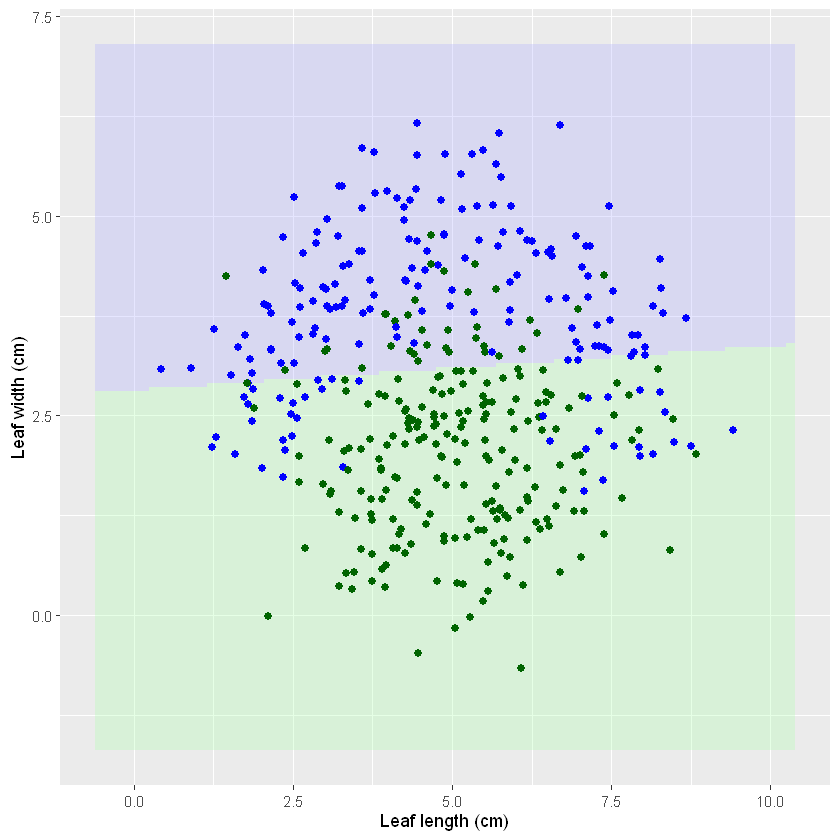

In [9]:
X <- leaf_data[, c("Leaf.length", "Leaf.width")]
y <- as.numeric(leaf_data$Species == "Species A")  # 1 if species A, else 0

# leaf_data <- data.frame(X, y = y)

log_reg <- glm(y ~ Leaf.length + Leaf.width, data = leaf_data, family = binomial())

h <- 0.05  # step size in the mesh

x1_min <- min(X$Leaf.length) - 1
x1_max <- max(X$Leaf.length) + 1
x2_min <- min(X$Leaf.width) - 1
x2_max <- max(X$Leaf.width) + 1

xx1 <- seq(x1_min, x1_max, by = h)
xx2 <- seq(x2_min, x2_max, by = h)
grid <- expand.grid(Leaf.length = xx1, Leaf.width = xx2)

grid$prob <- predict(log_reg, newdata = grid, type = "response")
grid$prediction <- factor(ifelse(grid$prob > 0.5, 1, 0))

ggplot() +
  geom_tile(data = grid, aes(x = Leaf.length, y = Leaf.width, 
            fill = prediction), alpha = 0.3) +
  geom_point(data = leaf_data, aes(x = Leaf.length, y = Leaf.width, 
             color = factor(y)), size = 2) +
  scale_fill_manual(values = c("0" = "#aaffaa", "1" = "#aaaaff")) +
  scale_color_manual(values = c("0" = "#006400", "1" = "#0000ff")) +
  labs(x = "Leaf length (cm)", y = "Leaf width (cm)") +
  theme(legend.position = "none")


Observing the above plot it can be said that this linear logistic model has clearly misclassifies data and thus has done underfitting.

In [14]:
k <- 2  # order of polynomial fit

X <- leaf_data[, c("Leaf.length", "Leaf.width")]
y <- as.numeric(leaf_data$Species == "Species A")  # 1 if Iris virginica, else 0



log_reg <- glm(y ~ poly(Leaf.length, k, raw = TRUE) + 
                   poly(Leaf.width, k, raw = TRUE), 
               data = leaf_data, family = binomial())


Grid size: 38940 


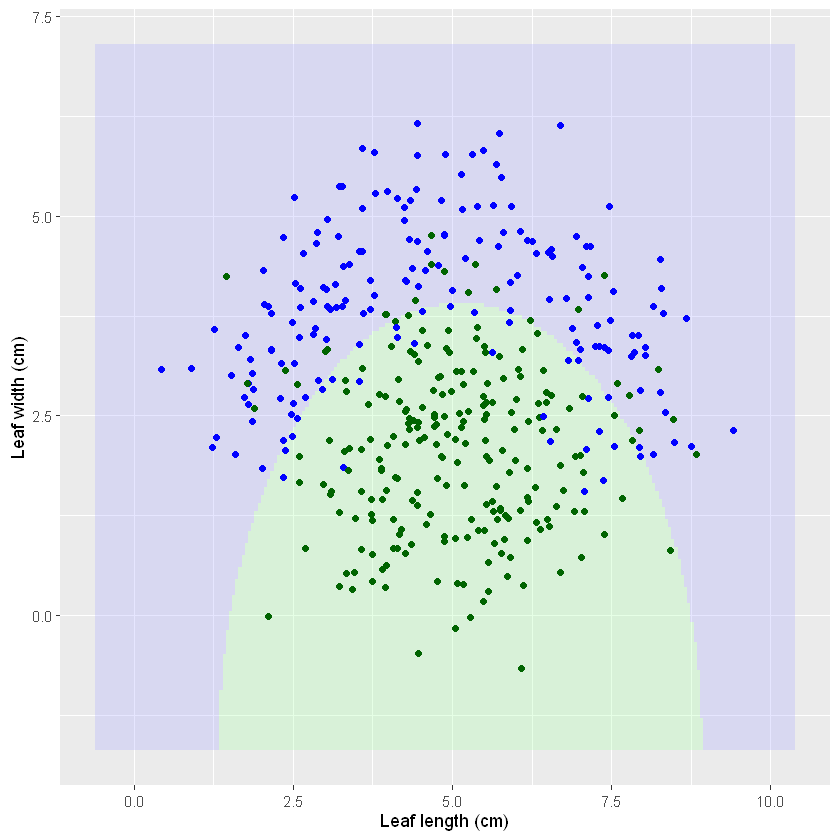

In [15]:
h <- 0.05  # step size in the mesh

x1_min <- min(X$Leaf.length) - 1
x1_max <- max(X$Leaf.length) + 1
x2_min <- min(X$Leaf.width) - 1
x2_max <- max(X$Leaf.width) + 1

xx1 <- seq(x1_min, x1_max, by = h)
xx2 <- seq(x2_min, x2_max, by = h)
grid <- expand.grid(Leaf.length = xx1, Leaf.width = xx2)

grid$prob <- predict(log_reg, newdata = grid, type = "response")
grid$prediction <- factor(ifelse(grid$prob > 0.5, 1, 0))

cat("Grid size:", nrow(grid), "\n")

ggplot() +
  geom_tile(data = grid, aes(x = Leaf.length, y = Leaf.width, 
            fill = prediction), alpha = 0.3) +
  geom_point(data = leaf_data, aes(x = Leaf.length, y = Leaf.width, 
             color = factor(y))) +
  scale_fill_manual(values = c("0" = "#aaffaa", "1" = "#aaaaff")) +
  scale_color_manual(values = c("0" = "#006400", "1" = "#0000ff")) +
  labs(x = "Leaf length (cm)", y = "Leaf width (cm)") +
  theme(legend.position = "none")


Observing the above plot of degree 2 logistic regression, it appears the model's performance has increased than the linear model but still misclassifies the data. So this polynomial is underfitting the data.

In [49]:
k <- 3  # order of polynomial fit

X <- leaf_data[, c("Leaf.length", "Leaf.width")]
y <- as.numeric(leaf_data$Species == "Species A")  # 1 if Iris virginica, else 0

# iris_data <- data.frame(X, y = y)

log_reg <- glm(y ~ poly(Leaf.length, k, raw = TRUE) + 
                   poly(Leaf.width, k, raw = TRUE), 
               data = leaf_data, family = binomial())


Grid size: 38940 


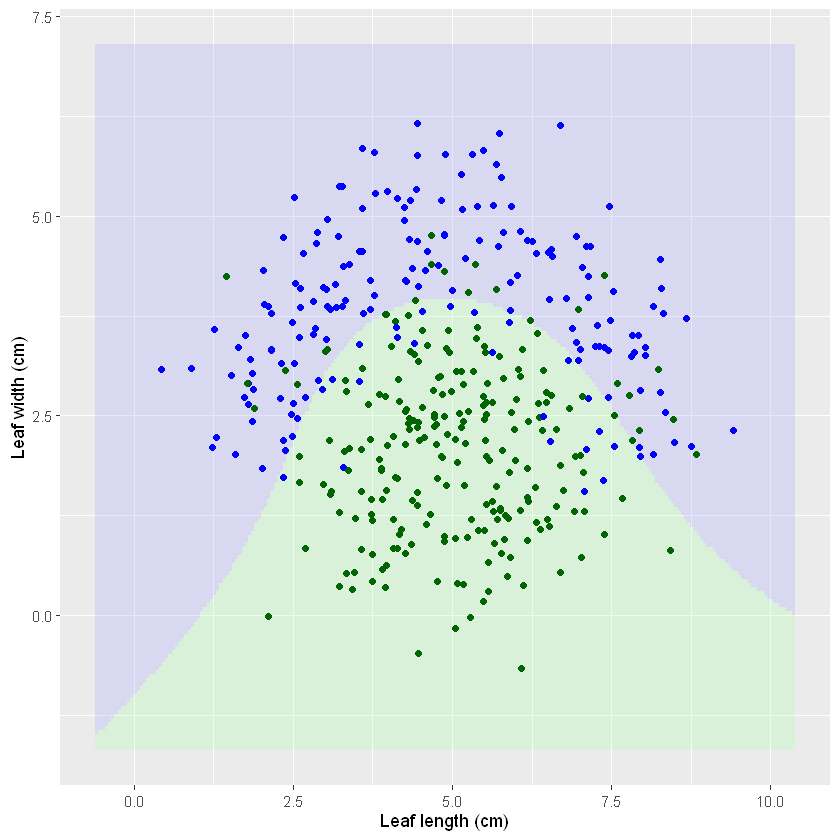

In [50]:
h <- 0.05  # step size in the mesh

x1_min <- min(X$Leaf.length) - 1
x1_max <- max(X$Leaf.length) + 1
x2_min <- min(X$Leaf.width) - 1
x2_max <- max(X$Leaf.width) + 1

xx1 <- seq(x1_min, x1_max, by = h)
xx2 <- seq(x2_min, x2_max, by = h)
grid <- expand.grid(Leaf.length = xx1, Leaf.width = xx2)

grid$prob <- predict(log_reg, newdata = grid, type = "response")
grid$prediction <- factor(ifelse(grid$prob > 0.5, 1, 0))

cat("Grid size:", nrow(grid), "\n")

ggplot() +
  geom_tile(data = grid, aes(x = Leaf.length, y = Leaf.width, 
            fill = prediction), alpha = 0.3) +
  geom_point(data = leaf_data, aes(x = Leaf.length, y = Leaf.width, 
             color = factor(y))) +
  scale_fill_manual(values = c("0" = "#aaffaa", "1" = "#aaaaff")) +
  scale_color_manual(values = c("0" = "#006400", "1" = "#0000ff")) +
  labs(x = "Leaf length (cm)", y = "Leaf width (cm)") +
  theme(legend.position = "none")


The plot above of 3rd degree polynomial logistic regression appears to classify the data much better than the previous two models. This can also be seen from the highest accuracy that the 3rd degree model displays when evaluated on the test data above.

In [51]:
k <- 4  # order of polynomial fit

X <- leaf_data[, c("Leaf.length", "Leaf.width")]
y <- as.numeric(leaf_data$Species == "Species A")  # 1 if Iris virginica, else 0

# iris_data <- data.frame(X, y = y)

log_reg <- glm(y ~ poly(Leaf.length, k, raw = TRUE) + 
                   poly(Leaf.width, k, raw = TRUE), 
               data = leaf_data, family = binomial())


Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"


Grid size: 38940 


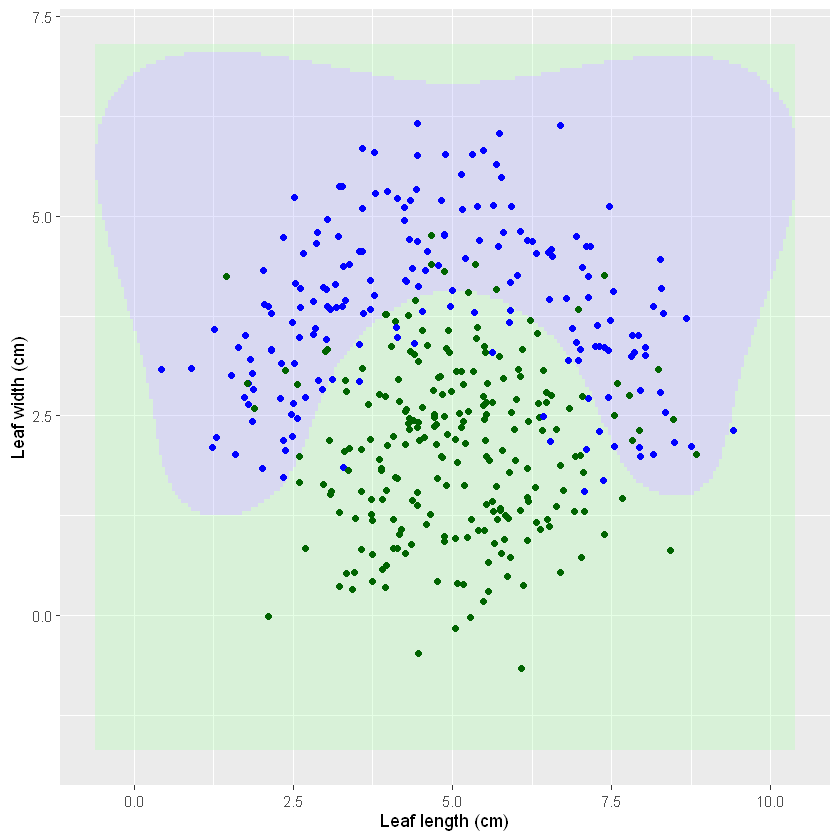

In [52]:
h <- 0.05  # step size in the mesh

x1_min <- min(X$Leaf.length) - 1
x1_max <- max(X$Leaf.length) + 1
x2_min <- min(X$Leaf.width) - 1
x2_max <- max(X$Leaf.width) + 1

xx1 <- seq(x1_min, x1_max, by = h)
xx2 <- seq(x2_min, x2_max, by = h)
grid <- expand.grid(Leaf.length = xx1, Leaf.width = xx2)

grid$prob <- predict(log_reg, newdata = grid, type = "response")
grid$prediction <- factor(ifelse(grid$prob > 0.5, 1, 0))

cat("Grid size:", nrow(grid), "\n")

ggplot() +
  geom_tile(data = grid, aes(x = Leaf.length, y = Leaf.width, 
            fill = prediction), alpha = 0.3) +
  geom_point(data = leaf_data, aes(x = Leaf.length, y = Leaf.width, 
             color = factor(y))) +
  scale_fill_manual(values = c("0" = "#aaffaa", "1" = "#aaaaff")) +
  scale_color_manual(values = c("0" = "#006400", "1" = "#0000ff")) +
  labs(x = "Leaf length (cm)", y = "Leaf width (cm)") +
  theme(legend.position = "none")


The above plot of 4th degree polynomial completelly overfits the data and it can be concluded that a polynomial of degree 3 is the best fit for the dataset.